## 1. Setup

In [1]:
# Install the latest Ultralytics package (includes YOLO11 classification models)
!uv pip install -q ultralytics scikit-learn matplotlib pandas seaborn 


In [2]:
!uv pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu126

Checked 3 packages in 10ms


In [3]:
import os
import shutil
from pathlib import Path
from collections import defaultdict

import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import pandas as pd
import numpy as np

from ultralytics import YOLO
import torch


import ultralytics
print("Ultralytics version:", ultralytics.__version__)
print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


Ultralytics version: 8.4.90
Torch version: 2.12.1+cu126
CUDA available: True
GPU: NVIDIA GeForce RTX 4050 Laptop GPU


## 2. Configuration

Set `DATA_ROOT` to the folder that directly contains your `train`, `test`, and `valid`
folders. Everything below adapts automatically to whatever classes it finds.


In [ ]:
# ==== EDIT THIS ====
DATA_ROOT = Path("./roof_dataset")  
# ====================

SPLIT_FOLDER_NAMES = {
    "train": "train",
    "val":   "valid",  
    "test":  "test",
}

IGNORE_FOLDERS = {"unlabled", "unlabeled"}

IMG_EXTENSIONS = {".jpg", ".jpeg", ".png"}

MODEL_NAME  = "yolo26m-cls.pt"   #
IMG_SIZE    = 416
EPOCHS      = 50
BATCH       = 64
PROJECT_DIR = "runs_roof_classify"
RUN_NAME    = "roof_yolo26_cls_night"

assert DATA_ROOT.exists(), f"DATA_ROOT does not exist: {DATA_ROOT.resolve()}"
print("Using data root:", DATA_ROOT.resolve())


Using data root: C:\Users\Jeobel\Downloads\Roof-Type-Classifier.v1i.folder\roof_dataset


## 3. Inspect the dataset & reconcile class mismatches

First we scan every split and report:
- which classes exist in each split
- image counts per class
- which classes are missing from which split (the mismatch problem described above)


In [5]:
def scan_split(split_path: Path):
    """Return {class_name: image_count} for a split directory."""
    counts = {}
    if not split_path.exists():
        return counts
    for class_dir in sorted(split_path.iterdir()):
        if not class_dir.is_dir():
            continue
        if class_dir.name.lower() in IGNORE_FOLDERS:
            continue
        n = sum(1 for f in class_dir.rglob("*") if f.suffix.lower() in IMG_EXTENSIONS)
        counts[class_dir.name] = n
    return counts

split_counts = {}
for yolo_split, folder_name in SPLIT_FOLDER_NAMES.items():
    split_counts[yolo_split] = scan_split(DATA_ROOT / folder_name)

df = pd.DataFrame(split_counts).fillna(0).astype(int)
df.loc["TOTAL"] = df.sum()
df


,train,val,test
complex,19,5,3
complex flat,1,0,0
complex gable hip,1,0,0
flat,163,27,17
flat gable,4,1,0
gable,261,50,37
gable hip,4,0,0
gable pyramid,1,0,0
hip,235,51,34
pyramid,14,6,3


In [6]:
all_classes   = set(df.index) - {"TOTAL"}
train_classes = set(k for k, v in split_counts["train"].items() if v > 0)
val_classes   = set(k for k, v in split_counts["val"].items() if v > 0)
test_classes  = set(k for k, v in split_counts["test"].items() if v > 0)

print("Classes only in train (never seen in val/test):", sorted(train_classes - val_classes - test_classes))
print("Classes in val but NOT in train             :", sorted(val_classes - train_classes))
print("Classes in test but NOT in train             :", sorted(test_classes - train_classes))
print("Classes in val but NOT in test               :", sorted(val_classes - test_classes))
print("Classes in test but NOT in val               :", sorted(test_classes - val_classes))
print()
print("--> Any class listed as 'in val/test but NOT in train' CANNOT be learned by the")
print("    model — there are zero training examples for it. Reconcile these below")
print("    (e.g. by merging folder names) before training, or accept lower accuracy")
print("    on those classes.")


Classes only in train (never seen in val/test): ['complex flat', 'complex gable hip', 'gable hip', 'gable pyramid']
Classes in val but NOT in train             : []
Classes in test but NOT in train             : []
Classes in val but NOT in test               : ['flat gable']
Classes in test but NOT in val               : []

--> Any class listed as 'in val/test but NOT in train' CANNOT be learned by the
    model — there are zero training examples for it. Reconcile these below
    (e.g. by merging folder names) before training, or accept lower accuracy
    on those classes.


### 3a. (Optional) Reconcile class names

If you know, e.g., that your `train/gable hip` folder is really the same roof type as
`valid/hip` + a secondary feature, decide here how to merge/rename folders so all three
splits agree. Edit `CLASS_RENAME_MAP` below — keys are original folder names (any split),
values are the **canonical class name** you want to train on. Leave it empty (`{}`) to
use the raw folder names as-is (mismatches and all — not recommended, but the notebook
will still run and just report lower coverage for missing classes).

A reasonable default is provided that keeps the 5 simple test classes as the canonical
set and folds every "combined" train folder into its dominant single class so training
data isn't wasted. **Adjust this mapping to match your domain knowledge** — this is a
judgment call the notebook can't make for you.


In [ ]:
# Map "raw folder name" -> "canonical class name to actually train on"
CLASS_RENAME_MAP = {
    "complex flat":        "complex",
    "complex gable hip":   "complex",
    "gable hip":           "hip",
    "gable pyramid":       "gable",
    "flat gable":          "gable",   
}

def canonical(name: str) -> str:
    return CLASS_RENAME_MAP.get(name, name)

print("Canonical class set after mapping:")
print(sorted({canonical(c) for c in all_classes}))


Canonical class set after mapping:
['complex', 'flat', 'gable', 'hip', 'pyramid']


In [ ]:
YOLO_DATA_ROOT = Path("./yolo_dataset")

def build_symlink_dataset():
    if YOLO_DATA_ROOT.exists():
        shutil.rmtree(YOLO_DATA_ROOT)

    for yolo_split, folder_name in SPLIT_FOLDER_NAMES.items():
        src_split_dir = DATA_ROOT / folder_name
        if not src_split_dir.exists():
            print(f"[skip] {src_split_dir} does not exist")
            continue

        for class_dir in sorted(src_split_dir.iterdir()):
            if not class_dir.is_dir() or class_dir.name.lower() in IGNORE_FOLDERS:
                continue

            target_class = canonical(class_dir.name)
            dst_class_dir = YOLO_DATA_ROOT / yolo_split / target_class
            dst_class_dir.mkdir(parents=True, exist_ok=True)

            for img_path in class_dir.rglob("*"):
                if img_path.suffix.lower() not in IMG_EXTENSIONS:
                    continue
                # prefix with original folder name to avoid filename collisions
                # when several source folders map to the same canonical class
                link_name = f"{class_dir.name.replace(' ', '_')}__{img_path.name}"
                dst_path = dst_class_dir / link_name
                if not dst_path.exists():
                    try:
                        os.symlink(img_path.resolve(), dst_path)
                    except OSError:
                        shutil.copy2(img_path, dst_path)

    print("Built dataset at:", YOLO_DATA_ROOT.resolve())

build_symlink_dataset()

final_counts = {}
for yolo_split in SPLIT_FOLDER_NAMES:
    split_dir = YOLO_DATA_ROOT / yolo_split
    counts = {}
    if split_dir.exists():
        for class_dir in sorted(split_dir.iterdir()):
            counts[class_dir.name] = len(list(class_dir.glob("*")))
    final_counts[yolo_split] = counts

final_df = pd.DataFrame(final_counts).fillna(0).astype(int)
final_df.loc["TOTAL"] = final_df.sum()
final_df


Built dataset at: C:\Users\Jeobel\Downloads\Roof-Type-Classifier.v1i.folder\yolo_dataset


,train,val,test
complex,21,5,3
flat,163,27,17
gable,266,51,37
hip,239,51,34
pyramid,14,6,3
TOTAL,703,140,94


## 5. Visualize class balance and sample images

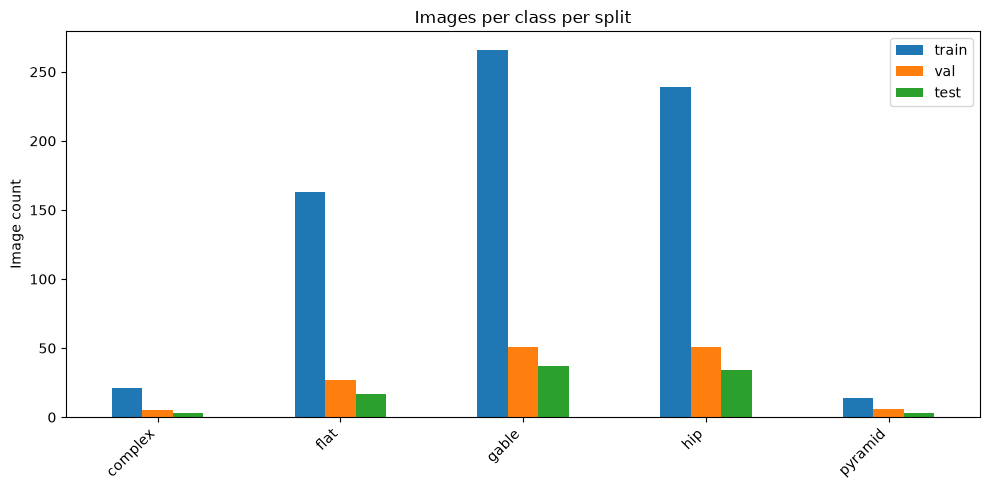

In [9]:
final_df.drop("TOTAL").plot(kind="bar", figsize=(10, 5))
plt.title("Images per class per split")
plt.ylabel("Image count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


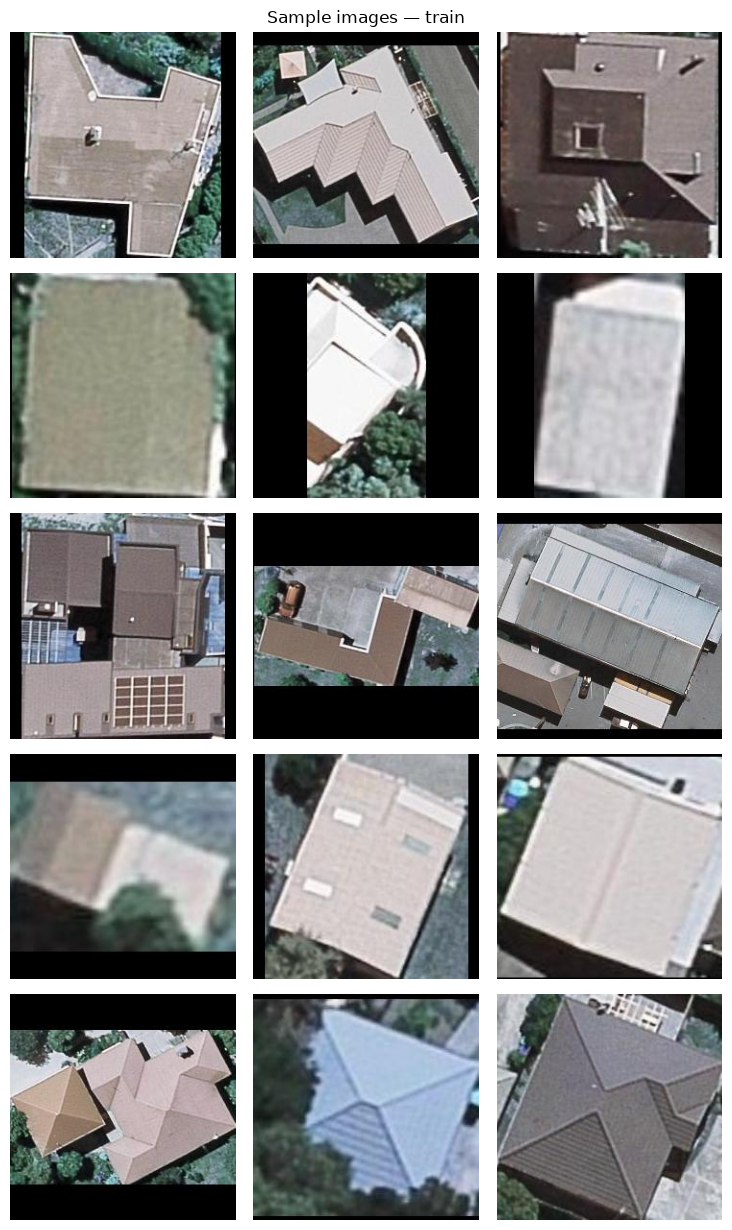

In [10]:
def show_samples(split="train", n_per_class=3):
    split_dir = YOLO_DATA_ROOT / split
    classes = sorted([d for d in split_dir.iterdir() if d.is_dir()])
    fig, axes = plt.subplots(len(classes), n_per_class, figsize=(n_per_class * 2.5, len(classes) * 2.5))
    if len(classes) == 1:
        axes = np.array([axes])
    for row, class_dir in enumerate(classes):
        imgs = list(class_dir.glob("*"))[:n_per_class]
        for col in range(n_per_class):
            ax = axes[row, col] if n_per_class > 1 else axes[row]
            ax.axis("off")
            if col < len(imgs):
                try:
                    ax.imshow(mpimg.imread(imgs[col]))
                except Exception:
                    pass
            if col == 0:
                ax.set_ylabel(class_dir.name, rotation=0, labelpad=40, fontsize=9)
    plt.suptitle(f"Sample images — {split}")
    plt.tight_layout()
    plt.show()

show_samples("train", n_per_class=3)


In [11]:
model = YOLO(MODEL_NAME)

results = model.tune(
    data=str(YOLO_DATA_ROOT.resolve()),
    epochs=50,
    iterations=80,
    device = 0
)

Tuner: Initialized Tuner instance with 'tune_dir=C:\Users\Jeobel\Downloads\Roof-Type-Classifier.v1i.folder\runs\classify\tune-8'
Tuner:  Learn about tuning at https://docs.ultralytics.com/guides/hyperparameter-tuning
Tuner: Starting iteration 1/80 with hyperparameters: {'lr0': 0.01, 'lrf': 0.01, 'momentum': 0.937, 'weight_decay': 0.0005, 'warmup_epochs': 3.0, 'warmup_momentum': 0.8, 'box': 7.5, 'cls': 0.5, 'cls_pw': 0.0, 'dfl': 1.5, 'hsv_h': 0.015, 'hsv_s': 0.7, 'hsv_v': 0.4, 'degrees': 0.0, 'translate': 0.1, 'scale': 0.5, 'shear': 0.0, 'perspective': 0.0, 'flipud': 0.0, 'fliplr': 0.5, 'bgr': 0.0, 'mosaic': 1.0, 'mixup': 0.0, 'cutmix': 0.0, 'copy_paste': 0.0, 'close_mosaic': 10}
Saved C:\Users\Jeobel\Downloads\Roof-Type-Classifier.v1i.folder\runs\classify\tune-8\tune_scatter_plots.png
Saved C:\Users\Jeobel\Downloads\Roof-Type-Classifier.v1i.folder\runs\classify\tune-8\tune_fitness.png

Tuner: 1/80 iterations complete  (266.16s)
Tuner: Results saved to C:\Users\Jeobel\Downloads\Roof-Typ

In [12]:
from pathlib import Path

tune_dir = max(
    Path("runs/classify").glob("tune*"),
    key=lambda p: p.stat().st_mtime
)

best_params_path = tune_dir / "best_hyperparameters.yaml"

print(best_params_path)

runs\classify\tune-8\best_hyperparameters.yaml


In [15]:
import yaml

with open(best_params_path, "r") as f:
    best_hyperparameters = yaml.safe_load(f)

model = YOLO(MODEL_NAME)

final_result = model.train(
    data=str(YOLO_DATA_ROOT.resolve()),
    epochs=500,
    imgsz=416,
    **best_hyperparameters
)

New https://pypi.org/project/ultralytics/8.4.91 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.90  Python-3.14.6 torch-2.12.1+cu126 CUDA:0 (NVIDIA GeForce RTX 4050 Laptop GPU, 6140MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.01141, box=5.62668, cache=False, cfg=None, classes=None, close_mosaic=3, cls=0.6726, cls_pw=0.00132, compile=False, conf=None, copy_paste=0.00038, copy_paste_mode=flip, cos_lr=False, cutmix=0.00162, data=C:\Users\Jeobel\Downloads\Roof-Type-Classifier.v1i.folder\yolo_dataset, degrees=0.00264, deterministic=True, device=, dfl=0.94929, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=500, erasing=0.4, exist_ok=False, fliplr=0.84076, flipud=0.00793, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.01689, hsv_s=0.63988, hsv_v=0.29128, imgsz=416, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.00594, lrf=0.01327, 

## 7. Training curves

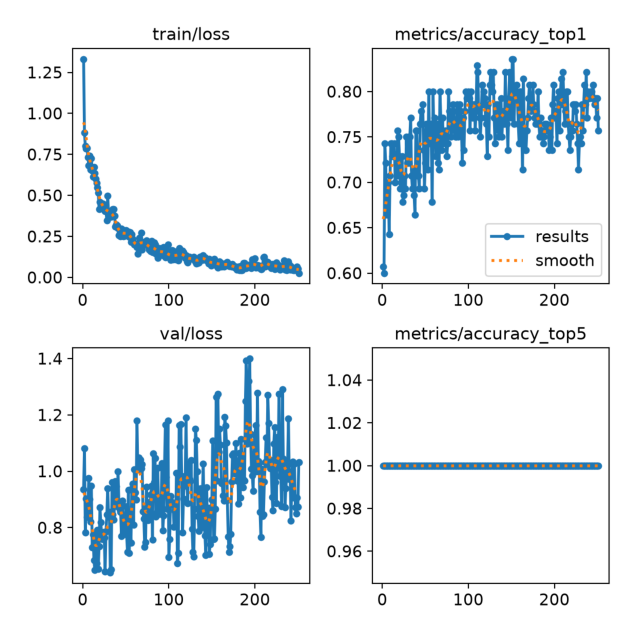

In [16]:
run_dir = final_result.save_dir
results_png = run_dir / "results.png"
if results_png.exists():
    img = mpimg.imread(results_png)
    plt.figure(figsize=(14, 8))
    plt.imshow(img)
    plt.axis("off")
    plt.show()
else:
    print("results.png not found yet at", results_png)


## 8. Validate on the `valid` split

In [19]:
run_dir = Path(final_result.save_dir)
best_weights = run_dir / "weights" / "best.pt"

best_model = YOLO(str(best_weights))

# Validate the best checkpoint
metrics = best_model.val(
    data=str(YOLO_DATA_ROOT.resolve()),
    split="val",
    imgsz=416,
)

print(metrics.results_dict)
print("Top-1:", metrics.top1)
print("Top-5:", metrics.top5)

Ultralytics 8.4.90  Python-3.14.6 torch-2.12.1+cu126 CUDA:0 (NVIDIA GeForce RTX 4050 Laptop GPU, 6140MiB)
YOLO26m-cls summary (fused): 57 layers, 10,348,037 parameters, 0 gradients, 39.3 GFLOPs
train: C:\Users\Jeobel\Downloads\Roof-Type-Classifier.v1i.folder\yolo_dataset\train... found 703 images in 5 classes  
val: C:\Users\Jeobel\Downloads\Roof-Type-Classifier.v1i.folder\yolo_dataset\val... found 140 images in 5 classes  
test: C:\Users\Jeobel\Downloads\Roof-Type-Classifier.v1i.folder\yolo_dataset\test... found 94 images in 5 classes  
val: Fast image access  (ping: 0.10.0 ms, read: 87.929.7 MB/s, size: 10.4 KB)
val: Scanning C:\Users\Jeobel\Downloads\Roof-Type-Classifier.v1i.folder\yolo_dataset\val... 140 images, 0 corrupt: 100% ━━━━━━━━━━━━ 140/140 41.9Mit/s 0.0s
               classes   top1_acc   top5_acc: 100% ━━━━━━━━━━━━ 9/9 1.2it/s 7.6s<0.1s
                   all      0.836          1
Speed: 0.4ms preprocess, 6.5ms inference, 0.0ms loss, 0.0ms postprocess per image
Results s

## 9. Evaluate on the held-out `test` split

              precision    recall  f1-score   support

     complex       0.00      0.00      0.00         3
        flat       0.56      0.82      0.67        17
       gable       0.90      0.70      0.79        37
         hip       0.82      0.94      0.88        34
     pyramid       0.00      0.00      0.00         3

    accuracy                           0.77        94
   macro avg       0.46      0.49      0.47        94
weighted avg       0.75      0.77      0.75        94



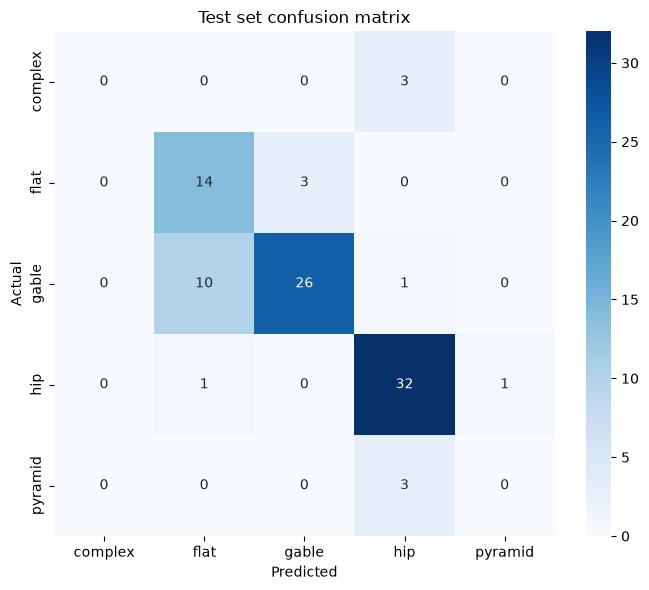

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

test_dir = YOLO_DATA_ROOT / "test"
y_true, y_pred = [], []
class_names = best_model.names 

for class_dir in sorted(test_dir.iterdir()):
    true_label = class_dir.name
    img_paths = list(class_dir.glob("*"))
    if not img_paths:
        continue
    preds = best_model.predict(img_paths, imgsz=IMG_SIZE, verbose=False)
    for p in preds:
        pred_label = class_names[int(p.probs.top1)]
        y_true.append(true_label)
        y_pred.append(pred_label)

labels_sorted = sorted(set(y_true) | set(y_pred))
print(classification_report(y_true, y_pred, labels=labels_sorted, zero_division=0))

cm = confusion_matrix(y_true, y_pred, labels=labels_sorted)
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=labels_sorted, yticklabels=labels_sorted, cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Test set confusion matrix")
plt.tight_layout()
plt.show()


## 10. Run inference on a single new image

In [21]:
def predict_roof(image_path, top_k=3):
    result = best_model.predict(image_path, imgsz=IMG_SIZE, verbose=False)[0]
    probs = result.probs
    top_idxs = probs.top5[:top_k]
    top_confs = probs.top5conf[:top_k].tolist()

    plt.figure(figsize=(4, 4))
    plt.imshow(mpimg.imread(image_path))
    plt.axis("off")
    title = "\n".join(f"{class_names[i]}: {c:.2%}" for i, c in zip(top_idxs, top_confs))
    plt.title(title, fontsize=10)
    plt.show()

    return [(class_names[i], c) for i, c in zip(top_idxs, top_confs)]

# Example usage:
# predict_roof("path/to/new_roof_photo.jpg")


In [22]:
FINAL_MODEL_PATH = "roof_classifier_best.pt"
shutil.copy2(best_weights, FINAL_MODEL_PATH)
print("Saved:", FINAL_MODEL_PATH)

# Optional: export to ONNX for deployment outside Python/Ultralytics
# best_model.export(format="onnx")


Saved: roof_classifier_best.pt


In [23]:
import os

test_dir = os.path.join(DATA_ROOT, "test")
sample_dir = test_dir if os.path.isdir(test_dir) else os.path.join(DATA_ROOT, "val")

shown = 0
for cls_name in os.listdir(sample_dir):
    cls_path = os.path.join(sample_dir, cls_name)
    if not os.path.isdir(cls_path):
        continue
    for img_name in os.listdir(cls_path)[:2]:
        result = model(os.path.join(cls_path, img_name))
        result[0].show()
        shown += 1
    if shown >= 10:
        break


image 1/1 c:\Users\Jeobel\Downloads\Roof-Type-Classifier.v1i.folder\roof_dataset\test\complex\1031_jpg.rf.cc4f7bcfcea2bc6070a0ba9373a91d7a.jpg: 416x416 hip 1.00, gable 0.00, complex 0.00, pyramid 0.00, flat 0.00, 6.9ms
Speed: 3.6ms preprocess, 6.9ms inference, 0.0ms postprocess per image at shape (1, 3, 416, 416)

image 1/1 c:\Users\Jeobel\Downloads\Roof-Type-Classifier.v1i.folder\roof_dataset\test\complex\1765_jpg.rf.1c6eb3dbefac0181ee61823d993318ce.jpg: 416x416 hip 1.00, flat 0.00, gable 0.00, pyramid 0.00, complex 0.00, 9.1ms
Speed: 4.5ms preprocess, 9.1ms inference, 0.0ms postprocess per image at shape (1, 3, 416, 416)

image 1/1 c:\Users\Jeobel\Downloads\Roof-Type-Classifier.v1i.folder\roof_dataset\test\flat\1081_jpg.rf.f5eabaf8930bc4c5b69b93a2bf279451.jpg: 416x416 gable 0.81, flat 0.18, hip 0.01, pyramid 0.00, complex 0.00, 15.1ms
Speed: 3.8ms preprocess, 15.1ms inference, 0.0ms postprocess per image at shape (1, 3, 416, 416)

image 1/1 c:\Users\Jeobel\Downloads\Roof-Type-Classi